# Training 

In [58]:
### lIBRAIRIES 

In [124]:
!pip install ucimlrepo
!pip install prophet


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   --------------------------------- ------ 10.2/12.1 MB 49.8 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 45.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 60.7 MB/s  0:00:00

   ------------- -------------------------- 2/6 [importlib_resources]
   -------------------- ------------------- 3/6 [holidays]
   -------------------- ------------------- 3/6 [holidays]
   -------------------- ------------------- 3/6 [holidays]
   -------------------- ------------------- 3/6 [holidays]
   -------------------- ------------------- 3/6 [holidays]
   -------------------- ------------------- 3/6 [holidays]
   -------------------------- ------------- 4/6 [cmdstanpy]
   --------------------------------- ------ 5/6 [prophet]
   --------------------------------- ------ 5/6 [prophet]
   ----------------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [138]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
from sklearn.model_selection import TimeSeriesSplit 
from prophet import Prophet
from ucimlrepo import fetch_ucirepo 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

### Téléchargement du jeu de données (x) et y la target à prédire 

In [61]:
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
# data (as pandas dataframes) 
x = online_retail.data.features 
y = online_retail.data.targets 
  
# metadata 
print(online_retail.metadata) 
  
# variable information 
print(online_retail.variables) 


{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

### Aperçu du dataframe et des colonnes de variables 

In [62]:
x.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [63]:
x.dtypes

Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

###### Note : on va garder seulement les premières 1000 lignes pour alléger la mémoire vu que c'est de l'entrainement 

In [64]:
# x=x[:1000]
x.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


###### Note : au final, on ne supprimera pas les lignes étant donné le projet de prévision avec les séries temp, on a besoin de davantage de lignes pour coder 

### Traitement des données (NA,etc...)

In [65]:
x.isna().sum()
x.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


###### Note : on pourrait vouloir leur ajouter une description de consommation ainsi qu'un ID customer mais cela implique un biais si on utilise l'aléatoire pour l'ID par exemple donc on va simplement supprimer la ligne 

###### Note : on va donc supprimer toutes les lignes avec des valeurs manquantes 

In [66]:
x.dropna(inplace=True)
x.describe()

C:\Users\thoma\AppData\Local\Temp\ipykernel_17808\1062358878.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.dropna(inplace=True)


,Quantity,UnitPrice,CustomerID
count,406829.000000,406829.000000,406829.000000
mean,12.061303,3.460471,15287.690570
std,248.693370,69.315162,1713.600303
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13953.000000
50%,5.000000,1.950000,15152.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Vérification de la présence de NA après suppression 

In [67]:
x.isna().sum()

Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [68]:
x

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...
541904,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


# Mission que l'on s'octroie 

### Faire des stats descriptives 

###### Note : Dans un premier temps, on va garder ce premier df dans une optique d'utiliser les K-means ou autre modèle de ML non supervisé afin de réaliser une segmentation des clients puis on créera un second df qui reprendra le CA par jour du magasin ainsi que les dépenses par clients journalières pour pouvoir prédire le CA mensuel ou hebdo du magasin et tenter d'utiliser les modèles LOF pour voir si le magasin ne présente pas d'activités suspectes 

In [69]:
x.dtypes

Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

### Utiliser les Kmeans pour segmenter les clients 

###### Note : on copie le dataframe x dans un dataframe temporaire df pour ne pas interférer avec les données puis on va y implémenter une variable motnant qui reprend les sommes dépensées et on modifie aussi les types de colonnes 

In [70]:
df=x.copy()
df['Amount']=x['Quantity']*x['UnitPrice']
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [71]:
df['Date']=df['InvoiceDate'].dt.date 
df.drop('InvoiceDate',axis=1,inplace=True)
df

,Description,Quantity,UnitPrice,CustomerID,Country,Amount,Date
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,15.30,2010-12-01
1,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,20.34,2010-12-01
2,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,22.00,2010-12-01
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,20.34,2010-12-01
4,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,20.34,2010-12-01
...,...,...,...,...,...,...,...
541904,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,10.20,2011-12-09
541905,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,12.60,2011-12-09
541906,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,16.60,2011-12-09
541907,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,16.60,2011-12-09


###### Note : étant donné le peu d'information que l'on possède, on n'utilisera pas les Kmeans mais plutot la RFM qui est plus simple et demande moins de ressources data 

### RFM 

##### Recency --> temps écoulé depuis le dernier achat 

###### Note : on part du postulat que la date de référence est la dernière date globale appliquée

###### Note : on calcule aussi la date du dernier achat de chaque client 

In [72]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
date_ref=max(df['Date'])
date_client=df.groupby('CustomerID')['Date'].max()

In [73]:
print(date_client.dtype)  # doit afficher datetime64[ns]

datetime64[ns]


##### RFM par client 

In [74]:
### recency 
R=(date_ref - date_client).dt.days

def get_nbr_transaction(df):
    freq=df.groupby('CustomerID').size()
    return freq

M = df.groupby('CustomerID')['Amount'].sum()
    

###### Note : on crée un dataframe par client en fonction des 3 indicateurs 

In [75]:
rfm=pd.DataFrame({
    'Recency (days)':R,
    'Frequency (transactions)':get_nbr_transaction(df),
    'M ($)':M
})

In [76]:
rfm.head()

,Recency (days),Frequency (transactions),M ($)
CustomerID,,,
12346.0,325,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,18,73,1757.55
12350.0,310,17,334.40


### Scoring

###### Note : on divise la population quantiles, score de 1 à 5,  plus le score est élevé, 
###### plus R petit, plus score élevé
###### plus F grand, plus score élevé
###### plus M grand, plus score élevé 

In [77]:
rfm['R_score']=pd.qcut(rfm['Recency (days)'],5,labels=[1,2,3,4,5])
rfm['Freq_score']=pd.qcut(rfm['Frequency (transactions)'].rank(method='first'),5,labels=[1,2,3,4,5])
rfm['M_score']=pd.qcut(rfm['M ($)'],5,labels=[1,2,3,4,5])

### Combinaison des scores pour RFM_score 

In [78]:
rfm['RFM_score'] = rfm['R_score'].astype(int)*100 + rfm['Freq_score'].astype(int)*10 + rfm['M_score'].astype(int)

### Création d'une variable catégorielle 

In [79]:
def Cat(row):
    R = row['R_score']
    F = row['Freq_score']
    M = row['M_score']
    
    if R >= 4 and F >= 4 and M >= 4:
        return "Très bon acheteur"
    elif R >= 4 and F <= 2:
        return "Nouveau client"
    elif F >= 4 and M <= 2:
        return "Fidèle petit dépensier"
    elif R <= 2:
        return "À relancer"
    elif 3 <= R <= 4 and 3 <= F <= 4:
        return "Acheteur régulier"
    elif M >= 4 and F <= 2:
        return "Gros dépensier irrégulier"
    else:
        return "Acheteur moyen"

rfm['Catégorie'] = rfm.apply(Cat, axis=1)

In [80]:
rfm

,Recency (days),Frequency (transactions),M ($),R_score,Freq_score,M_score,RFM_score,Catégorie
CustomerID,,,,,,,,
12346.0,325,2,0.00,5,1,1,511,Nouveau client
12347.0,2,182,4310.00,1,5,5,155,À relancer
12348.0,75,31,1797.24,4,3,4,434,Acheteur régulier
12349.0,18,73,1757.55,2,4,4,244,À relancer
12350.0,310,17,334.40,5,2,2,522,Nouveau client
...,...,...,...,...,...,...,...,...
18280.0,277,10,180.60,5,1,1,511,Nouveau client
18281.0,180,7,80.82,5,1,1,511,Nouveau client
18282.0,7,13,176.60,1,1,1,111,À relancer


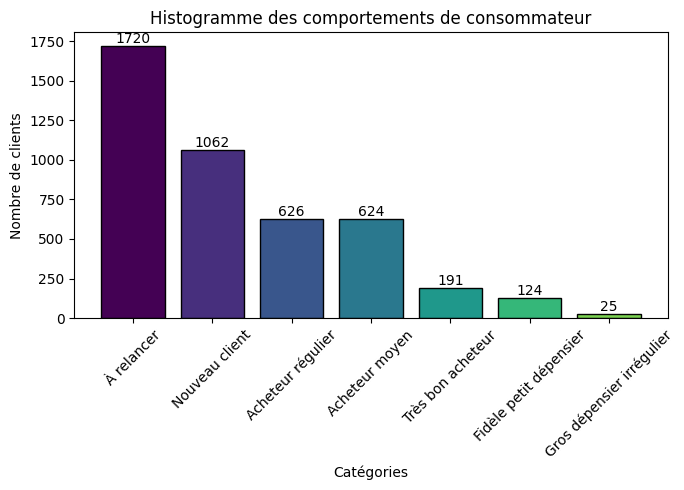

In [81]:
counts = rfm['Catégorie'].value_counts()

categories = counts.index
valeurs = counts.values
n = len(categories)
plt.figure(figsize=(7,5))
colors = cm.viridis(np.linspace(0,0.8,n))
plt.bar(categories, valeurs, color=colors, edgecolor='black')
for i, val in enumerate(valeurs):
    plt.text(i, val + 0.1, str(val), ha='center', va='bottom')
plt.xlabel("Catégories")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=45)
plt.title("Histogramme des comportements de consommateur")
plt.tight_layout()
plt.show()


### Conclusion de l'étude 

###### Note : besoin de retravailler la politique de fidélisation des clients car une majorité de clients à relancer et de nouveaux clients à fidéliser 

### Prédiction de CA 

###### note : on change de df pour pouvoir prédire le CA journalier du magasin 

In [84]:
df_ca=df.copy()

,Description,Quantity,UnitPrice,CustomerID,Country,Amount,Date
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,15.30,2010-12-01
1,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,20.34,2010-12-01
2,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,22.00,2010-12-01
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,20.34,2010-12-01
4,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,20.34,2010-12-01
...,...,...,...,...,...,...,...
541904,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,10.20,2011-12-09
541905,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,12.60,2011-12-09
541906,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,16.60,2011-12-09
541907,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,16.60,2011-12-09


In [86]:
ca_journalier = df_ca.groupby('Date')['Amount'].sum().reset_index()
ca_journalier.rename(columns={'Amount':'CA'}, inplace=True)

,Date,CA
0,2010-12-01,46051.26
1,2010-12-02,45775.43
2,2010-12-03,22598.46
3,2010-12-05,31380.60
4,2010-12-06,30465.08
...,...,...
300,2011-12-05,56634.53
301,2011-12-06,43659.20
302,2011-12-07,68991.27
303,2011-12-08,49442.19


###### Note : on doit enrichir les données donc on va en rajouter de manière à pouvoir entrainer le modèle sur une plus grande quantité 

In [89]:
ca_journalier['Weekday']=ca_journalier['Date'].dt.weekday

###### Note : on peut rajouter d'autres périodes pour les saisonalités par exemple 

In [91]:
ca_journalier['month'] = ca_journalier['Date'].dt.month
ca_journalier['quarter'] = ca_journalier['Date'].dt.quarter
ca_journalier['year'] = ca_journalier['Date'].dt.year

###### Note : on peut rajouter les lags qui permettent de corréler le CA du jours avec celui de la veille et celui 7 jours auparavant 

In [99]:
ca_journalier['CA_lag1'] = ca_journalier['CA'].shift(1)   # CA de la veille
ca_journalier['CA_lag7'] = ca_journalier['CA'].shift(7)   # CA d'il y a une semaine

In [100]:
ca_journalier

,Date,CA,Weekday,month,quarter,year,CA_lag1,CA_lag7
0,2010-12-01,46051.26,2,12,4,2010,NaN,NaN
1,2010-12-02,45775.43,3,12,4,2010,46051.26,NaN
2,2010-12-03,22598.46,4,12,4,2010,45775.43,NaN
3,2010-12-05,31380.60,6,12,4,2010,22598.46,NaN
4,2010-12-06,30465.08,0,12,4,2010,31380.60,NaN
...,...,...,...,...,...,...,...,...
300,2011-12-05,56634.53,0,12,4,2011,20320.31,17261.38
301,2011-12-06,43659.20,1,12,4,2011,56634.53,50108.50
302,2011-12-07,68991.27,2,12,4,2011,43659.20,48474.95
303,2011-12-08,49442.19,3,12,4,2011,68991.27,40520.85


###### Note : également des features de moyenne récentes avec les rolling features 

In [102]:
ca_journalier['CA_rolling7'] = ca_journalier['CA'].rolling(7).mean()
ca_journalier['CA_rolling30'] = ca_journalier['CA'].rolling(30).mean()


In [104]:
ca_journalier.isna().sum()

Date             0
CA               0
Weekday          0
month            0
quarter          0
year             0
CA_lag1          1
CA_lag7          7
CA_rolling7      6
CA_rolling30    29
dtype: int64

###### Note : on va supprimer la feature rolling30 car ça nous ferait supprimer environ 10% des données pour le modèle et on supprimera les dernières lignes contenant des NaN 

In [110]:
ca_journalier.drop('CA_rolling30',axis=1,inplace=True)
ca_journalier=ca_journalier.dropna()
ca_journalier.describe()

,Date,CA,Weekday,month,quarter,year,CA_lag1,CA_lag7,CA_rolling7
count,298,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000
mean,2011-06-15 06:12:04.832214784,26955.101725,2.681208,6.510067,2.500000,2010.956376,27030.566389,26850.075248,26916.651217
min,2010-12-09 00:00:00,3457.110000,0.000000,1.000000,1.000000,2010.000000,3457.110000,3457.110000,11448.914286
25%,2011-03-16 06:00:00,17208.560000,1.000000,3.250000,1.250000,2011.000000,17222.850000,17222.850000,19831.471071
50%,2011-06-18 00:00:00,23261.125000,3.000000,7.000000,3.000000,2011.000000,23297.485000,23297.485000,23976.088571
75%,2011-09-13 18:00:00,33336.510000,4.000000,9.000000,3.000000,2011.000000,33543.390000,33105.802500,33108.335000
max,2011-12-09 00:00:00,103385.260000,6.000000,12.000000,4.000000,2011.000000,103385.260000,103385.260000,49544.698571
std,NaN,14682.889573,1.949458,3.405516,1.116904,0.204601,14681.918030,14413.590316,9204.730484


### Prédiction 

###### Note : on définit les features et la target pour préparer les données au ml 

In [136]:
X=ca_journalier.drop(['CA','Date'],axis=1)
y=ca_journalier['CA']

###### Note : on ne fait pas un simple train-test split pour ne pas chevaucher la temporalité et donc on utilise TimeSeriesSplit de sklearn 

In [133]:
tscv = TimeSeriesSplit(n_splits=5)

#### !! Note importante !! : Je n'ai pas poussé l'économétrie en regardant la stationarité de la série car c'est un entrainement mais bien entedu, il est très important de le faire sinon les biais créés sont énormes 

###### Note : On utilise donc Prophet et une RandomForest pour comparer 

#### 1. RandomForest

In [139]:
mae_scores = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    model = RandomForestRegressor(n_estimators=300)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)
    
    print(f"MAE pour ce split : {mae:.2f}")

print(f"MAE moyen : {np.mean(mae_scores):.2f}")


MAE pour ce split : 5508.92
MAE pour ce split : 6336.64
MAE pour ce split : 8012.50
MAE pour ce split : 11082.28
MAE pour ce split : 9557.10
MAE moyen : 8099.49


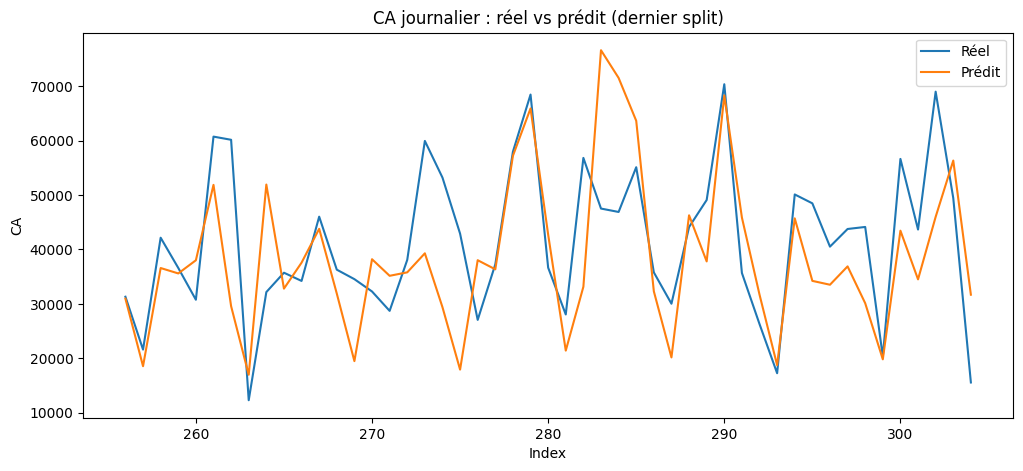

In [140]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Réel")
plt.plot(y_test.index, y_pred, label="Prédit")
plt.title("CA journalier : réel vs prédit (dernier split)")
plt.xlabel("Index")
plt.ylabel("CA")
plt.legend()
plt.show()

### Prophet 

In [142]:
for train_index, test_index in tscv.split(df_prophet):
    train_df = df_prophet.iloc[train_index]
    test_df  = df_prophet.iloc[test_index]
    
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.fit(train_df)
    
    future = model.make_future_dataframe(periods=len(test_df), freq='D', include_history=False)
    
    forecast = model.predict(future)
    
    mae = mean_absolute_error(test_df['y'], forecast['yhat'])
    mae_scores.append(mae)
    
    print(f"MAE pour ce split : {mae:.2f}")

print(f"MAE moyen : {np.mean(mae_scores):.2f}")


NameError: name 'df_prophet' is not defined

In [144]:
X = ca_journalier[['Date', 'CA']].rename(columns={'Date': 'ds', 'CA': 'y'})

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
mae_scores = []

for train_index, test_index in tscv.split(X):
    train_df = X.iloc[train_index]
    test_df  = X.iloc[test_index]
    
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.fit(train_df)
    
    future = model.make_future_dataframe(periods=len(test_df), freq='D', include_history=False)
    
    forecast = model.predict(future)
    
    mae = mean_absolute_error(test_df['y'], forecast['yhat'])
    mae_scores.append(mae)
    
    print(f"MAE pour ce split : {mae:.2f}")

print(f"MAE moyen : {np.mean(mae_scores):.2f}")


16:14:11 - cmdstanpy - INFO - Chain [1] start processing
16:14:14 - cmdstanpy - INFO - Chain [1] done processing
16:14:14 - cmdstanpy - INFO - Chain [1] start processing
16:14:14 - cmdstanpy - INFO - Chain [1] done processing


MAE pour ce split : 695501.78
MAE pour ce split : 16491.30


16:14:15 - cmdstanpy - INFO - Chain [1] start processing
16:14:15 - cmdstanpy - INFO - Chain [1] done processing
16:14:15 - cmdstanpy - INFO - Chain [1] start processing
16:14:15 - cmdstanpy - INFO - Chain [1] done processing


MAE pour ce split : 11833.75
MAE pour ce split : 22140.56


16:14:15 - cmdstanpy - INFO - Chain [1] start processing
16:14:15 - cmdstanpy - INFO - Chain [1] done processing


MAE pour ce split : 23178.05
MAE moyen : 153829.09


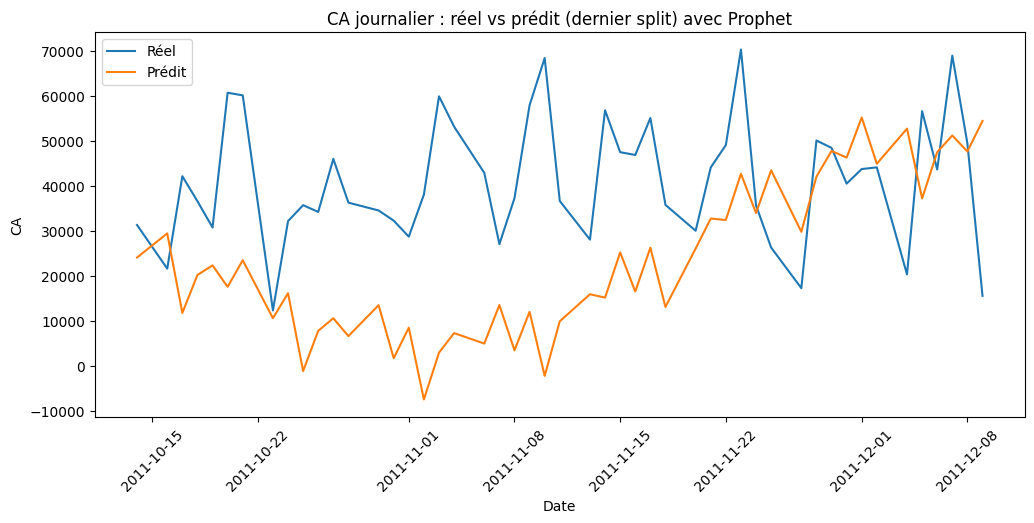

In [146]:
plt.figure(figsize=(12,5))
plt.plot(test_df['ds'], test_df['y'], label="Réel")
plt.plot(test_df['ds'], forecast['yhat'], label="Prédit")
plt.title("CA journalier : réel vs prédit (dernier split) avec Prophet")
plt.xlabel("Date")
plt.ylabel("CA")
plt.xticks(rotation=45)
plt.legend()
plt.show()

###### Note : les résultats de Prophet ne sont vraiment pas bon donc la RandomForest meilleure mais le modèle peut être amélioré avec plus de données, des meilleures feature et potentiellement des hyperparametres adaptés à notre tâche. 
### Fin du module 